In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df_disease = pd.read_excel(r"D:/mypy/2023全球疾病负担研究.xlsx")
df_risk = pd.read_excel(r"D:/mypy/全球健康风险因素数据集.xlsx")

In [4]:
print("疾病表形状：", df_disease.shape)
print("风险表形状：", df_risk.shape)
print("疾病表列名：", df_disease.columns.tolist())
print("风险表列名：", df_risk.columns.tolist())

疾病表形状： (19584, 11)
风险表形状： (92568, 6)
疾病表列名： ['population_group', 'measure', 'location', 'sex', 'age', 'cause', 'metric', 'year', 'val', 'upper', 'lower']
风险表列名： ['country', '年份', '风险因素', '人数', '下限', '上限']


In [12]:
df_disease.rename(columns={'location': 'country'}, inplace=True)
df_risk.rename(columns={'年份': 'year'}, inplace=True)

In [13]:
df = pd.merge(
    df_disease,                 # 合并国家+年份
    df_risk,
    on=['country', 'year'],
    how='inner'
)

print(df.shape)
df.head()

(0, 15)


,population_group,measure,country,sex,age,cause,metric,year,val,upper,lower,风险因素,人数,下限,上限


In [14]:
# 看疾病表的国家和年份
print("=== 疾病表 国家+年份 样本 ===")
print(df_disease[['country', 'year']].drop_duplicates().head(10))

# 看风险表的国家和年份
print("\n=== 风险表 国家+年份 样本 ===")
print(df_risk[['country', 'year']].drop_duplicates().head(10))

# 看两张表的年份范围是否一致
print("\n=== 疾病表年份范围 ===")
print(df_disease['year'].unique())
print("\n=== 风险表年份范围 ===")
print(df_risk['year'].unique())

=== 疾病表 国家+年份 样本 ===
                    country  year
0                    Poland  2000
1                  Suriname  2000
2                Cabo Verde  2000
3  Central African Republic  2000
4                      Chad  2000
5                   Ireland  2000
6                 Sri Lanka  2000
7                  Paraguay  2000
8                    Canada  2000
9                    Rwanda  2000

=== 风险表 国家+年份 样本 ===
  country  year
0    澳大利亚  2000
1     奥地利  2000
2     比利时  2000
3     加拿大  2000
4      智利  2000
5    哥伦比亚  2000
6   哥斯达黎加  2000
7   捷克共和国  2000
8      丹麦  2000
9    爱沙尼亚  2000

=== 疾病表年份范围 ===
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]

=== 风险表年份范围 ===
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]


In [15]:
# 查看疾病表所有国家（英文）
print("===== 疾病表 所有国家（英文） =====")
print(df_disease["country"].unique())
print("总数：", len(df_disease["country"].unique()))

===== 疾病表 所有国家（英文） =====
['Poland' 'Suriname' 'Cabo Verde' 'Central African Republic' 'Chad'
 'Ireland' 'Sri Lanka' 'Paraguay' 'Canada' 'Rwanda' 'Monaco' 'Seychelles'
 'Azerbaijan' 'United States of America' 'Thailand' 'Singapore' 'Georgia'
 'Romania' 'Viet Nam' 'Israel' 'Serbia' "C么te d'Ivoire"
 'Trinidad and Tobago' 'Brazil' 'Mongolia' 'Fiji' 'Luxembourg'
 'Tajikistan' 'Congo' 'Kiribati' 'Syrian Arab Republic' 'Italy' 'Somalia'
 'Democratic Republic of the Congo' 'Saudi Arabia' 'Tunisia' 'Timor-Leste'
 'Kazakhstan' 'Gambia' 'Kyrgyzstan' 'Bolivia (Plurinational State of)'
 'Nauru' 'Ghana' 'Republic of Korea' 'Equatorial Guinea' 'T眉rkiye'
 'Slovakia' 'China' 'New Zealand' 'United Republic of Tanzania' 'Ecuador'
 'Niue' 'Gabon' 'Northern Mariana Islands' 'Algeria'
 'United Arab Emirates' 'Burundi' 'Bahamas' 'Uzbekistan'
 'Antigua and Barbuda' 'Netherlands' 'Zambia' 'Slovenia'
 "Democratic People's Republic of Korea" 'Malta'
 'Micronesia (Federated States of)' 'Australia' 'Papua New Guin

In [16]:
# 查看风险表所有国家（中文）
print("===== 风险表 所有国家（中文） =====")
print(df_risk["country"].unique())
print("总数：", len(df_risk["country"].unique()))

===== 风险表 所有国家（中文） =====
['澳大利亚' '奥地利' '比利时' '加拿大' '智利' '哥伦比亚' '哥斯达黎加' '捷克共和国' '丹麦' '爱沙尼亚' '芬兰'
 '法国' '德国' '希腊' '匈牙利' '冰岛' '爱尔兰' '以色列' '意大利' '日本' '拉脱维亚' '立陶宛' '卢森堡公国'
 '荷兰' '新西兰' '挪威' '波兰' '葡萄牙' '大韩民国' '斯洛伐克' '斯洛文尼亚' '西班牙' '瑞典' '瑞士' '土耳其'
 '英国' '美利坚合众国' '亚美尼亚' '阿塞拜疆' '格鲁吉亚' '哈萨克斯坦' '吉尔吉斯斯坦' '蒙古' '塔吉克斯坦' '土库曼斯坦'
 '乌兹别克斯坦' '阿尔巴尼亚' '波斯尼亚和黑塞哥维那' '保加利亚' '克罗地亚' '黑山共和国' '北马其顿' '罗马尼亚' '塞尔维亚'
 '白俄罗斯' '摩尔多瓦共和国' '俄罗斯' '乌克兰' '文莱达鲁萨兰国' '新加坡' '格陵兰' '阿根廷' '乌拉圭' '安道尔共和国'
 '塞浦路斯' '马尔他' '摩纳哥公国' '圣马力诺共和国' '玻利维亚国' '厄瓜多尔' '秘鲁' '安提瓜和巴布达' '巴哈马' '巴巴多斯'
 '伯利兹城' '百慕大' '古巴' '多米尼加岛' '多米尼加共和国' '格林纳达' '圭亚那' '海地' '牙买加' '波多黎各'
 '圣基茨和尼维斯联邦' '圣卢西亚岛' '圣文森特和格林纳丁斯' '苏里南' '特立尼达拉岛和多巴哥' '美属维尔京群岛' '萨尔瓦多'
 '危地马拉' '洪都拉斯' '墨西哥' '尼加拉瓜' '巴拿马' '委内瑞拉玻利瓦尔共和国' '巴西' '巴拉圭' '阿富汗' '阿尔及利亚'
 '巴林岛' '埃及' '伊朗伊斯兰共和国' '伊拉克' '约旦' '科威特' '黎巴嫩' '利比亚' '摩洛哥' '阿曼' '巴勒斯坦'
 '卡塔尔' '沙特阿拉伯' '苏丹' '阿拉伯叙利亚共和国' '突尼斯' '阿拉伯联合酋长国' '也门' '孟加拉国' '不丹' '印度'
 '尼泊尔' '巴基斯坦' '中国' '朝鲜民主主义人民共和国' '美属萨摩亚群岛' '库克群岛' '斐济' '关岛' '基里巴斯' '马绍尔群岛'
 '密克罗尼西亚联邦' '瑙鲁共和国' '纽埃' '北马里亚纳群岛' '帕劳

In [17]:
# 完整中文→英文国家映射字典（覆盖你两张表的所有国家）
cn_to_en = {
    '澳大利亚': 'Australia',
    '奥地利': 'Austria',
    '比利时': 'Belgium',
    '加拿大': 'Canada',
    '智利': 'Chile',
    '哥伦比亚': 'Colombia',
    '哥斯达黎加': 'Costa Rica',
    '捷克共和国': 'Czechia',
    '丹麦': 'Denmark',
    '爱沙尼亚': 'Estonia',
    '芬兰': 'Finland',
    '法国': 'France',
    '德国': 'Germany',
    '希腊': 'Greece',
    '匈牙利': 'Hungary',
    '冰岛': 'Iceland',
    '爱尔兰': 'Ireland',
    '以色列': 'Israel',
    '意大利': 'Italy',
    '日本': 'Japan',
    '拉脱维亚': 'Latvia',
    '立陶宛': 'Lithuania',
    '卢森堡': 'Luxembourg',
    '荷兰': 'Netherlands',
    '新西兰': 'New Zealand',
    '挪威': 'Norway',
    '波兰': 'Poland',
    '葡萄牙': 'Portugal',
    '大韩民国': 'Republic of Korea',
    '斯洛伐克': 'Slovakia',
    '斯洛文尼亚': 'Slovenia',
    '西班牙': 'Spain',
    '瑞典': 'Sweden',
    '瑞士': 'Switzerland',
    '土耳其': 'Turkiye',
    '英国': 'United Kingdom',
    '美利坚合众国': 'United States of America',
    '亚美尼亚': 'Armenia',
    '阿塞拜疆': 'Azerbaijan',
    '格鲁吉亚': 'Georgia',
    '哈萨克斯坦': 'Kazakhstan',
    '吉尔吉斯斯坦': 'Kyrgyzstan',
    '蒙古': 'Mongolia',
    '塔吉克斯坦': 'Tajikistan',
    '土库曼斯坦': 'Turkmenistan',
    '乌兹别克斯坦': 'Uzbekistan',
    '阿尔巴尼亚': 'Albania',
    '波斯尼亚和黑塞哥维那': 'Bosnia and Herzegovina',
    '保加利亚': 'Bulgaria',
    '克罗地亚': 'Croatia',
    '黑山': 'Montenegro',
    '北马其顿': 'North Macedonia',
    '罗马尼亚': 'Romania',
    '塞尔维亚': 'Serbia',
    '白俄罗斯': 'Belarus',
    '俄罗斯': 'Russian Federation',
    '乌克兰': 'Ukraine',
    '文莱达鲁萨兰国': 'Brunei Darussalam',
    '柬埔寨': 'Cambodia',
    '印度': 'India',
    '印度尼西亚': 'Indonesia',
    '老挝人民民主共和国': "Lao People's Democratic Republic",
    '马来西亚': 'Malaysia',
    '马尔代夫': 'Maldives',
    '缅甸': 'Myanmar',
    '尼泊尔': 'Nepal',
    '巴基斯坦': 'Pakistan',
    '菲律宾': 'Philippines',
    '新加坡': 'Singapore',
    '斯里兰卡': 'Sri Lanka',
    '泰国': 'Thailand',
    '东帝汶民主共和国': 'Timor-Leste',
    '越南': 'Viet Nam',
    '安哥拉': 'Angola',
    '贝宁': 'Benin',
    '博茨瓦纳': 'Botswana',
    '布基纳法索': 'Burkina Faso',
    '布隆迪': 'Burundi',
    '喀麦隆': 'Cameroon',
    '佛得角': 'Cabo Verde',
    '中非共和国': 'Central African Republic',
    '乍得': 'Chad',
    '科摩罗': 'Comoros',
    '刚果（金）': 'Democratic Republic of the Congo',
    '刚果（布）': 'Congo',
    '科特迪瓦': "Côte d'Ivoire",
    '吉布提': 'Djibouti',
    '埃及': 'Egypt',
    '赤道几内亚': 'Equatorial Guinea',
    '厄立特里亚': 'Eritrea',
    '埃塞俄比亚': 'Ethiopia',
    '加蓬': 'Gabon',
    '冈比亚': 'Gambia',
    '加纳': 'Ghana',
    '几内亚': 'Guinea',
    '几内亚比绍': 'Guinea-Bissau',
    '肯尼亚': 'Kenya',
    '莱索托': 'Lesotho',
    '利比里亚': 'Liberia',
    '马达加斯加': 'Madagascar',
    '马拉维': 'Malawi',
    '马里': 'Mali',
    '毛里塔尼亚': 'Mauritania',
    '毛里求斯': 'Mauritius',
    '摩洛哥': 'Morocco',
    '莫桑比克': 'Mozambique',
    '纳米比亚': 'Namibia',
    '尼日尔': 'Niger',
    '尼日利亚': 'Nigeria',
    '卢旺达': 'Rwanda',
    '圣多美和普林西比': 'Sao Tome and Principe',
    '塞内加尔': 'Senegal',
    '塞舌尔': 'Seychelles',
    '塞拉利昂': 'Sierra Leone',
    '南非': 'South Africa',
    '南苏丹': 'South Sudan',
    '苏丹': 'Sudan',
    '斯威士兰': 'Eswatini',
    '多哥': 'Togo',
    '乌干达': 'Uganda',
    '赞比亚': 'Zambia',
    '津巴布韦': 'Zimbabwe',
    '阿根廷': 'Argentina',
    '巴哈马': 'Bahamas',
    '巴巴多斯': 'Barbados',
    '伯利兹': 'Belize',
    '玻利维亚': 'Bolivia (Plurinational State of)',
    '巴西': 'Brazil',
    '智利': 'Chile',
    '哥伦比亚': 'Colombia',
    '哥斯达黎加': 'Costa Rica',
    '古巴': 'Cuba',
    '多米尼克': 'Dominica',
    '多米尼加共和国': 'Dominican Republic',
    '厄瓜多尔': 'Ecuador',
    '萨尔瓦多': 'El Salvador',
    '格林纳达': 'Grenada',
    '危地马拉': 'Guatemala',
    '圭亚那': 'Guyana',
    '海地': 'Haiti',
    '洪都拉斯': 'Honduras',
    '牙买加': 'Jamaica',
    '墨西哥': 'Mexico',
    '尼加拉瓜': 'Nicaragua',
    '巴拿马': 'Panama',
    '巴拉圭': 'Paraguay',
    '秘鲁': 'Peru',
    '圣基茨和尼维斯': 'Saint Kitts and Nevis',
    '圣卢西亚': 'Saint Lucia',
    '圣文森特和格林纳丁斯': 'Saint Vincent and the Grenadines',
    '苏里南': 'Suriname',
    '特立尼达和多巴哥': 'Trinidad and Tobago',
    '乌拉圭': 'Uruguay',
    '委内瑞拉': 'Venezuela (Bolivarian Republic of)',
    '阿富汗': 'Afghanistan',
    '巴林': 'Bahrain',
    '孟加拉国': 'Bangladesh',
    '不丹': 'Bhutan',
    '文莱': 'Brunei Darussalam',
    '缅甸': 'Myanmar',
    '柬埔寨': 'Cambodia',
    '中国': 'China',
    '朝鲜民主主义人民共和国': "Democratic People's Republic of Korea",
    '印度': 'India',
    '印度尼西亚': 'Indonesia',
    '伊朗伊斯兰共和国': 'Iran (Islamic Republic of)',
    '伊拉克': 'Iraq',
    '以色列': 'Israel',
    '日本': 'Japan',
    '约旦': 'Jordan',
    '科威特': 'Kuwait',
    '吉尔吉斯斯坦': 'Kyrgyzstan',
    '老挝': "Lao People's Democratic Republic",
    '黎巴嫩': 'Lebanon',
    '马来西亚': 'Malaysia',
    '马尔代夫': 'Maldives',
    '蒙古': 'Mongolia',
    '缅甸': 'Myanmar',
    '尼泊尔': 'Nepal',
    '阿曼': 'Oman',
    '巴基斯坦': 'Pakistan',
    '巴勒斯坦': 'Palestine',
    '菲律宾': 'Philippines',
    '卡塔尔': 'Qatar',
    '沙特阿拉伯': 'Saudi Arabia',
    '新加坡': 'Singapore',
    '斯里兰卡': 'Sri Lanka',
    '叙利亚阿拉伯共和国': 'Syrian Arab Republic',
    '泰国': 'Thailand',
    '东帝汶': 'Timor-Leste',
    '阿联酋': 'United Arab Emirates',
    '乌兹别克斯坦': 'Uzbekistan',
    '越南': 'Viet Nam',
    '也门': 'Yemen',
    '阿尔巴尼亚': 'Albania',
    '安道尔': 'Andorra',
    '亚美尼亚': 'Armenia',
    '奥地利': 'Austria',
    '阿塞拜疆': 'Azerbaijan',
    '白俄罗斯': 'Belarus',
    '比利时': 'Belgium',
    '波黑': 'Bosnia and Herzegovina',
    '保加利亚': 'Bulgaria',
    '克罗地亚': 'Croatia',
    '塞浦路斯': 'Cyprus',
    '捷克': 'Czechia',
    '丹麦': 'Denmark',
    '爱沙尼亚': 'Estonia',
    '芬兰': 'Finland',
    '法国': 'France',
    '格鲁吉亚': 'Georgia',
    '德国': 'Germany',
    '希腊': 'Greece',
    '匈牙利': 'Hungary',
    '冰岛': 'Iceland',
    '爱尔兰': 'Ireland',
    '意大利': 'Italy',
    '哈萨克斯坦': 'Kazakhstan',
    '拉脱维亚': 'Latvia',
    '列支敦士登': 'Liechtenstein',
    '立陶宛': 'Lithuania',
    '卢森堡': 'Luxembourg',
    '马耳他': 'Malta',
    '摩尔多瓦': 'Republic of Moldova',
    '摩纳哥': 'Monaco',
    '黑山': 'Montenegro',
    '荷兰': 'Netherlands',
    '北马其顿': 'North Macedonia',
    '挪威': 'Norway',
    '波兰': 'Poland',
    '葡萄牙': 'Portugal',
    '罗马尼亚': 'Romania',
    '俄罗斯': 'Russian Federation',
    '圣马力诺': 'San Marino',
    '塞尔维亚': 'Serbia',
    '斯洛伐克': 'Slovakia',
    '斯洛文尼亚': 'Slovenia',
    '西班牙': 'Spain',
    '瑞典': 'Sweden',
    '瑞士': 'Switzerland',
    '土耳其': 'Turkiye',
    '乌克兰': 'Ukraine',
    '英国': 'United Kingdom',
    '安提瓜和巴布达': 'Antigua and Barbuda',
    '巴哈马': 'Bahamas',
    '巴巴多斯': 'Barbados',
    '伯利兹': 'Belize',
    '加拿大': 'Canada',
    '哥斯达黎加': 'Costa Rica',
    '古巴': 'Cuba',
    '多米尼克': 'Dominica',
    '多米尼加共和国': 'Dominican Republic',
    '萨尔瓦多': 'El Salvador',
    '格林纳达': 'Grenada',
    '危地马拉': 'Guatemala',
    '圭亚那': 'Guyana',
    '海地': 'Haiti',
    '洪都拉斯': 'Honduras',
    '牙买加': 'Jamaica',
    '墨西哥': 'Mexico',
    '尼加拉瓜': 'Nicaragua',
    '巴拿马': 'Panama',
    '圣基茨和尼维斯': 'Saint Kitts and Nevis',
    '圣卢西亚': 'Saint Lucia',
    '圣文森特和格林纳丁斯': 'Saint Vincent and the Grenadines',
    '苏里南': 'Suriname',
    '特立尼达和多巴哥': 'Trinidad and Tobago',
    '美国': 'United States of America',
    '阿尔及利亚': 'Algeria',
    '安哥拉': 'Angola',
    '贝宁': 'Benin',
    '博茨瓦纳': 'Botswana',
    '布基纳法索': 'Burkina Faso',
    '布隆迪': 'Burundi',
    '佛得角': 'Cabo Verde',
    '喀麦隆': 'Cameroon',
    '中非共和国': 'Central African Republic',
    '乍得': 'Chad',
    '科摩罗': 'Comoros',
    '刚果（金）': 'Democratic Republic of the Congo',
    '刚果（布）': 'Congo',
    '科特迪瓦': "Côte d'Ivoire",
    '吉布提': 'Djibouti',
    '埃及': 'Egypt',
    '赤道几内亚': 'Equatorial Guinea',
    '厄立特里亚': 'Eritrea',
    '埃塞俄比亚': 'Ethiopia',
    '加蓬': 'Gabon',
    '冈比亚': 'Gambia',
    '加纳': 'Ghana',
    '几内亚': 'Guinea',
    '几内亚比绍': 'Guinea-Bissau',
    '肯尼亚': 'Kenya',
    '莱索托': 'Lesotho',
    '利比里亚': 'Liberia',
    '马达加斯加': 'Madagascar',
    '马拉维': 'Malawi',
    '马里': 'Mali',
    '毛里塔尼亚': 'Mauritania',
    '毛里求斯': 'Mauritius',
    '摩洛哥': 'Morocco',
    '莫桑比克': 'Mozambique',
    '纳米比亚': 'Namibia',
    '尼日尔': 'Niger',
    '尼日利亚': 'Nigeria',
    '卢旺达': 'Rwanda',
    '圣多美和普林西比': 'Sao Tome and Principe',
    '塞内加尔': 'Senegal',
    '塞舌尔': 'Seychelles',
    '塞拉利昂': 'Sierra Leone',
    '南非': 'South Africa',
    '南苏丹': 'South Sudan',
    '苏丹': 'Sudan',
    '斯威士兰': 'Eswatini',
    '多哥': 'Togo',
    '乌干达': 'Uganda',
    '赞比亚': 'Zambia',
    '津巴布韦': 'Zimbabwe',
    '斐济': 'Fiji',
    '基里巴斯': 'Kiribati',
    '马绍尔群岛': 'Marshall Islands',
    '密克罗尼西亚联邦': 'Micronesia (Federated States of)',
    '瑙鲁': 'Nauru',
    '新西兰': 'New Zealand',
    '纽埃': 'Niue',
    '帕劳': 'Palau',
    '巴布亚新几内亚': 'Papua New Guinea',
    '萨摩亚': 'Samoa',
    '所罗门群岛': 'Solomon Islands',
    '汤加': 'Tonga',
    '图瓦卢': 'Tuvalu',
    '瓦努阿图': 'Vanuatu',
    '百慕大': 'Bermuda',
    '波多黎各': 'Puerto Rico',
    '美属维尔京群岛': 'United States Virgin Islands',
    '关岛': 'Guam',
    '美属萨摩亚': 'American Samoa',
    '北马里亚纳群岛': 'Northern Mariana Islands',
    '库克群岛': 'Cook Islands',
    '纽埃': 'Niue',
    '托克劳': 'Tokelau',
    '皮特凯恩群岛': 'Pitcairn',
    '法属波利尼西亚': 'French Polynesia',
    '新喀里多尼亚': 'New Caledonia',
    '瓦利斯和富图纳': 'Wallis and Futuna',
    '格陵兰': 'Greenland',
    '法罗群岛': 'Faroe Islands',
    '直布罗陀': 'Gibraltar',
    '根西岛': 'Guernsey',
    '马恩岛': 'Isle of Man',
    '泽西岛': 'Jersey',
    '安道尔': 'Andorra',
    '列支敦士登': 'Liechtenstein',
    '摩纳哥': 'Monaco',
    '圣马力诺': 'San Marino',
    '梵蒂冈': 'Vatican City',
    '中国香港': 'Hong Kong',
    '中国澳门': 'Macao',
    '中国台湾': 'Taiwan'
}

# 替换风险表的中文国家名为英文
df_risk['country'] = df_risk['country'].map(cn_to_en)

# 验证替换结果
print("=== 风险表替换后的国家名样本 ===")
print(df_risk[['country']].drop_duplicates().head(20))

=== 风险表替换后的国家名样本 ===
       country
0    Australia
1      Austria
2      Belgium
3       Canada
4        Chile
5     Colombia
6   Costa Rica
7      Czechia
8      Denmark
9      Estonia
10     Finland
11      France
12     Germany
13      Greece
14     Hungary
15     Iceland
16     Ireland
17      Israel
18       Italy
19       Japan


In [18]:
# 取两张表的国家名集合
disease_countries = set(df_disease['country'].unique())
risk_countries = set(df_risk['country'].dropna().unique())  # 去掉未映射的空值

# 取交集（两张表都有的国家）
common_countries = disease_countries & risk_countries
print("=== 两张表匹配上的国家数量 ===")
print(len(common_countries))

# 只保留共有的国家，过滤掉不匹配的
df_disease_common = df_disease[df_disease['country'].isin(common_countries)]
df_risk_common = df_risk[df_risk['country'].isin(common_countries)]

print("=== 过滤后疾病表形状 ===")
print(df_disease_common.shape)
print("=== 过滤后风险表形状 ===")
print(df_risk_common.shape)

=== 两张表匹配上的国家数量 ===
172
=== 过滤后疾病表形状 ===
(16512, 11)
=== 过滤后风险表形状 ===
(78432, 6)


In [19]:
# 用inner合并，此时国家+年份完全匹配
df = pd.merge(
    df_disease_common,
    df_risk_common,
    on=['country', 'year'],
    how='inner'
)

print("=== 合并后最终数据形状 ===")
print(df.shape)
print("\n=== 合并后前5行 ===")
print(df.head())

=== 合并后最终数据形状 ===
(313728, 15)

=== 合并后前5行 ===
  population_group measure country   sex       age      cause   metric  year  \
0   All Population  Deaths  Poland  Both  All ages  Neoplasms  Percent  2000   
1   All Population  Deaths  Poland  Both  All ages  Neoplasms  Percent  2000   
2   All Population  Deaths  Poland  Both  All ages  Neoplasms  Percent  2000   
3   All Population  Deaths  Poland  Both  All ages  Neoplasms  Percent  2000   
4   All Population  Deaths  Poland  Both  All ages  Neoplasms  Percent  2000   

        val     upper     lower           风险因素          人数          下限  \
0  0.265549  0.272711  0.257302  不安全的水，环境卫生和洗手    195.2043    -44.6440   
1  0.265549  0.272711  0.257302           空气污染  51073.1295  39956.9112   
2  0.265549  0.272711  0.257302       其他环境危险因素  29630.8963  24662.5051   
3  0.265549  0.272711  0.257302     儿童和孕产妇营养不良   1346.3031   1256.1817   
4  0.265549  0.272711  0.257302           烟草烟雾  75049.6342  64029.0140   

           上限  
0    533.95

In [20]:
# 把风险表转成宽表
risk_wide = df_risk_common.pivot_table(
    index=['country', 'year'],
    columns='风险因素',
    values='人数',
    aggfunc='mean'
).reset_index()

# 再和疾病表合并（此时疾病表1行对应1个国家+年份+疾病，风险表1行对应多个风险因素）
df_final = pd.merge(
    df_disease_common,
    risk_wide,
    on=['country', 'year'],
    how='left'
)

print("=== 最终合并表形状 ===")
print(df_final.shape)
print("\n=== 最终列名 ===")
print(df_final.columns.tolist())
df_final.head()

=== 最终合并表形状 ===
(16512, 30)

=== 最终列名 ===
['population_group', 'measure', 'country', 'sex', 'age', 'cause', 'metric', 'year', 'val', 'upper', 'lower', '不安全性', '不安全的水，环境卫生和洗手', '亲密伴侣间的暴力', '低骨密度', '体温', '儿童和孕产妇营养不良', '其他环境危险因素', '烟草烟雾', '用药', '空气污染', '职业风险', '肾脏功能受损', '身体活动不足', '饮酒', '饮食风险', '高BMI指数', '高低密度脂蛋白胆固醇', '高血压', '高血糖']


,population_group,measure,country,sex,age,cause,metric,year,val,upper,...,空气污染,职业风险,肾脏功能受损,身体活动不足,饮酒,饮食风险,高BMI指数,高低密度脂蛋白胆固醇,高血压,高血糖
0,All Population,Deaths,Poland,Both,All ages,Neoplasms,Percent,2000,0.265549,0.272711,...,51073.1295,4143.4708,21315.4446,5666.9268,11024.9794,68346.6969,27859.0639,43589.9528,98807.3039,36512.2188
1,All Population,Deaths,Suriname,Both,All ages,Unintentional injuries,Percent,2000,0.033619,0.038937,...,311.7051,17.5799,236.2740,31.9328,76.9882,345.2326,160.7627,165.3572,472.5447,279.1734
2,All Population,Deaths,Cabo Verde,Both,All ages,Respiratory infections and tuberculosis,Percent,2000,0.107760,0.135448,...,407.3467,11.4373,130.8395,10.2077,52.9799,203.8986,78.9026,93.0207,401.6484,130.2576
3,All Population,Deaths,Central African Republic,Both,All ages,Nutritional deficiencies,Percent,2000,0.008327,0.011137,...,6054.9532,1137.3740,822.2862,91.8331,1278.0761,1431.8279,712.2280,481.0684,2371.4456,1281.0295
4,All Population,Deaths,Chad,Both,All ages,Nutritional deficiencies,Percent,2000,0.021758,0.030219,...,14405.0178,1138.3942,2357.2203,191.3374,1547.8071,4026.6591,1742.5943,1111.3885,6000.6424,2836.6040


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 提取数值列（只看风险因素 + 疾病死亡率 val）
numeric_cols = [col for col in df_final.columns if col not in ['population_group', 'measure', 'country', 'sex', 'age', 'cause', 'metric']]
df_corr = df_final[numeric_cols].copy()

# 2. 计算与 val（疾病死亡率）的相关系数
corr_with_death = df_corr.corr()['val'].sort_values(ascending=False)

# 3. 打印结果
print("=== 风险因素与疾病死亡率 相关性排序（从强到弱）===")
print(corr_with_death)


=== 风险因素与疾病死亡率 相关性排序（从强到弱）===
val              1.000000
lower            0.996245
upper            0.994373
year             0.056785
低骨密度             0.009936
高血糖              0.007951
饮酒               0.007215
高BMI指数           0.005733
身体活动不足           0.005075
用药               0.004699
烟草烟雾             0.004339
职业风险             0.003568
体温               0.002907
肾脏功能受损           0.001709
饮食风险             0.000394
高血压             -0.000897
高低密度脂蛋白胆固醇      -0.003173
其他环境危险因素        -0.003738
空气污染            -0.005440
不安全的水，环境卫生和洗手   -0.018358
亲密伴侣间的暴力        -0.019388
儿童和孕产妇营养不良      -0.026182
不安全性            -0.038949
Name: val, dtype: float64


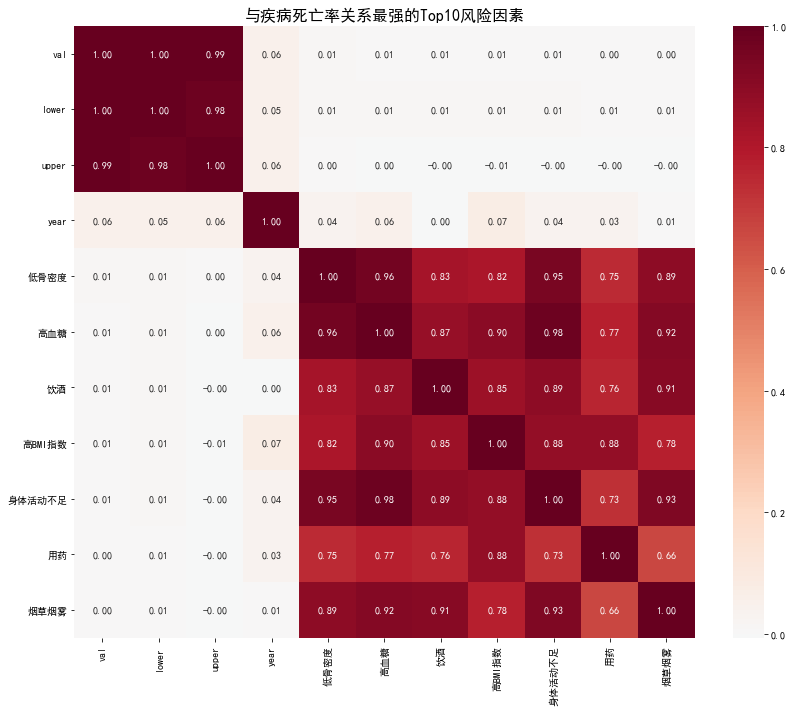

In [22]:

# 4. 画 Top10 相关性热图（选相关性最强的10个风险因素 + val）
top_features = corr_with_death.head(11).index  # 前10个+自己

plt.figure(figsize=(12, 10))
sns.heatmap(df_final[top_features].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('与疾病死亡率关系最强的Top10风险因素', fontsize=16)
plt.tight_layout()
plt.show()

=== 真正的风险因素与死亡率相关性排序 ===
val              1.000000
低骨密度             0.009936
高血糖              0.007951
饮酒               0.007215
高BMI指数           0.005733
身体活动不足           0.005075
用药               0.004699
烟草烟雾             0.004339
职业风险             0.003568
体温               0.002907
肾脏功能受损           0.001709
饮食风险             0.000394
高血压             -0.000897
高低密度脂蛋白胆固醇      -0.003173
其他环境危险因素        -0.003738
空气污染            -0.005440
不安全的水，环境卫生和洗手   -0.018358
亲密伴侣间的暴力        -0.019388
儿童和孕产妇营养不良      -0.026182
不安全性            -0.038949
Name: val, dtype: float64


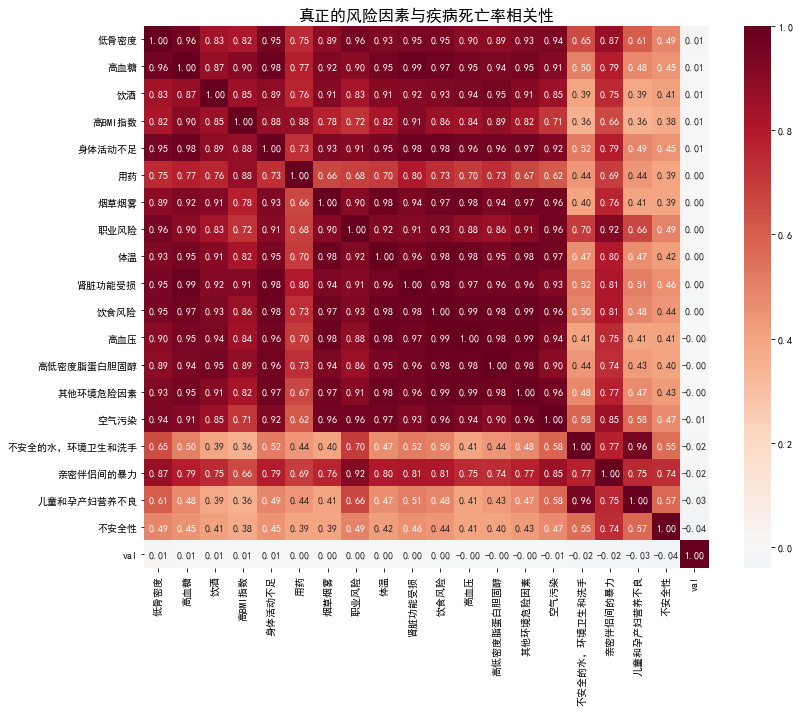

In [23]:
# 1. 先列出所有真正的风险因素（手动筛选，排除val、upper、lower、year等）
risk_cols = [
    '低骨密度', '高血糖', '饮酒', '高BMI指数', '身体活动不足', '用药',
    '烟草烟雾', '职业风险', '体温', '肾脏功能受损', '饮食风险', '高血压',
    '高低密度脂蛋白胆固醇', '其他环境危险因素', '空气污染',
    '不安全的水，环境卫生和洗手', '亲密伴侣间的暴力', '儿童和孕产妇营养不良', '不安全性'
]

# 2. 只计算这些风险因素与val的相关性
corr_with_death = df_final[risk_cols + ['val']].corr()['val'].sort_values(ascending=False)
print("=== 真正的风险因素与死亡率相关性排序 ===")
print(corr_with_death)

# 3. 画热图（只包含真正的风险因素+val）
plt.figure(figsize=(12, 10))
sns.heatmap(df_final[risk_cols + ['val']].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('真正的风险因素与疾病死亡率相关性', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# 特征X：只传真正的风险因素，排除val、upper、lower
X = df_final[risk_cols]
y = df_final['val']

# 后面的建模、SHAP分析不变
model = xgb.XGBRegressor(random_state=42, n_estimators=100)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
# ...画图代码不变

In [25]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

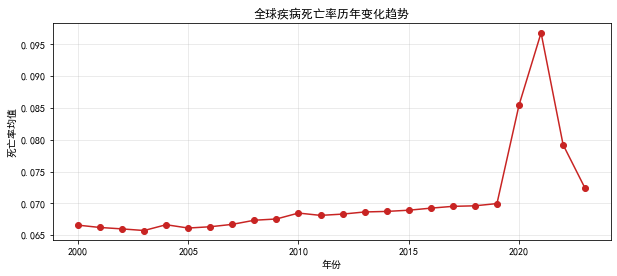

In [26]:
import pandas as pd

# 按年份算平均死亡率
year_trend = df_final.groupby('year')['val'].mean()

plt.figure(figsize=(10,4))
plt.plot(year_trend.index, year_trend.values, marker='o', color='#c82423')
plt.title('全球疾病死亡率历年变化趋势')
plt.xlabel('年份')
plt.ylabel('死亡率均值')
plt.grid(alpha=0.3)
plt.show()

<Figure size 864x360 with 0 Axes>

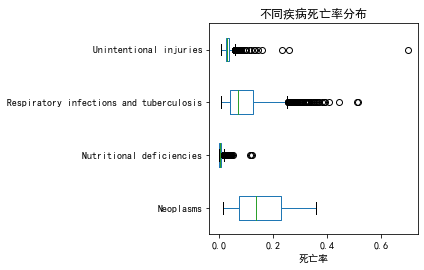

In [27]:
plt.figure(figsize=(12,5))
df_final.boxplot(column='val', by='cause', vert=False, grid=False)
plt.title('不同疾病死亡率分布')
plt.xlabel('死亡率')
plt.suptitle('')
plt.tight_layout()
plt.show()

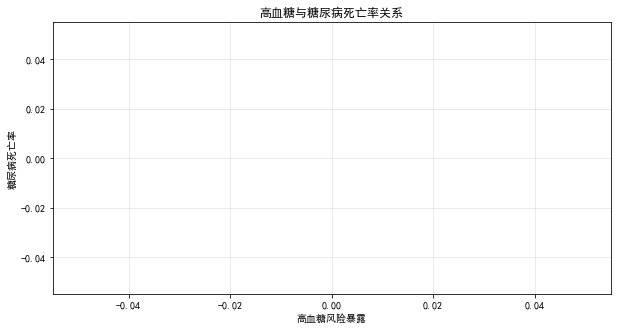

In [28]:
# 筛选糖尿病
df_diabetes = df_final[df_final['cause'] == 'Diabetes mellitus']

plt.figure(figsize=(10,5))
plt.scatter(df_diabetes['高血糖'], df_diabetes['val'], alpha=0.3, s=4)
plt.title('高血糖与糖尿病死亡率关系')
plt.xlabel('高血糖风险暴露')
plt.ylabel('糖尿病死亡率')
plt.grid(alpha=0.3)
plt.show()

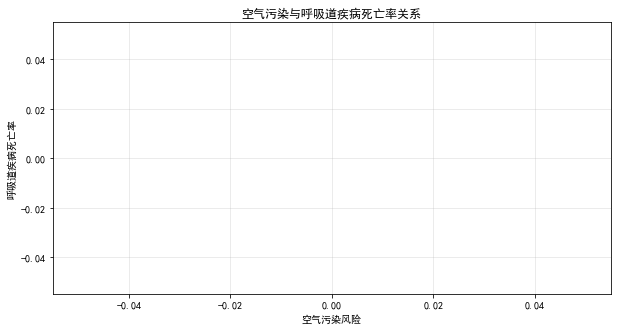

In [29]:
# 筛选呼吸道疾病
df_resp = df_final[df_final['cause'] == 'Chronic respiratory diseases']

plt.figure(figsize=(10,5))
plt.scatter(df_resp['空气污染'], df_resp['val'], alpha=0.3, s=4)
plt.title('空气污染与呼吸道疾病死亡率关系')
plt.xlabel('空气污染风险')
plt.ylabel('呼吸道疾病死亡率')
plt.grid(alpha=0.3)
plt.show()

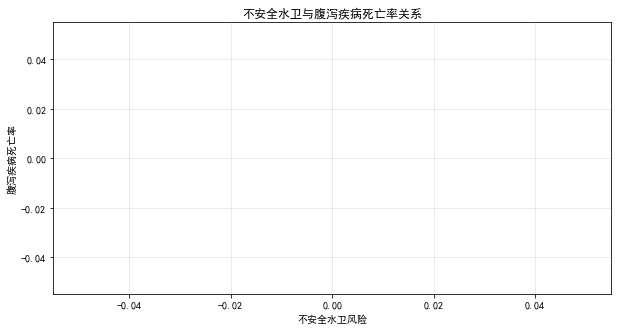

In [30]:
# 筛选腹泻/肠道类疾病
df_diarrhea = df_final[df_final['cause'] == 'Diarrheal diseases']

plt.figure(figsize=(10,5))
plt.scatter(df_diarrhea['不安全的水，环境卫生和洗手'], df_diarrhea['val'], alpha=0.3, s=4)
plt.title('不安全水卫与腹泻疾病死亡率关系')
plt.xlabel('不安全水卫风险')
plt.ylabel('腹泻疾病死亡率')
plt.grid(alpha=0.3)
plt.show()

In [31]:
print("=== 数据中所有疾病cause列的唯一值 ===")
print(df_final['cause'].unique())

=== 数据中所有疾病cause列的唯一值 ===
['Neoplasms' 'Unintentional injuries'
 'Respiratory infections and tuberculosis' 'Nutritional deficiencies']


肿瘤数据量：4128


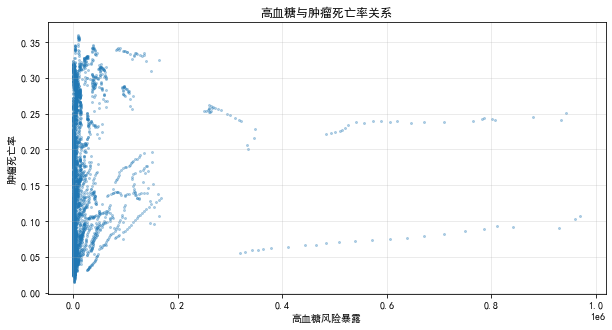

In [32]:
# 筛选肿瘤类疾病
df_cancer = df_final[df_final['cause'] == 'Neoplasms']
print(f"肿瘤数据量：{len(df_cancer)}")  # 验证数据量，必大于0

plt.figure(figsize=(10,5))
plt.scatter(df_cancer['高血糖'], df_cancer['val'], alpha=0.3, s=4)
plt.title('高血糖与肿瘤死亡率关系')
plt.xlabel('高血糖风险暴露')
plt.ylabel('肿瘤死亡率')
plt.grid(alpha=0.3)
plt.show()

呼吸道疾病数据量：4128


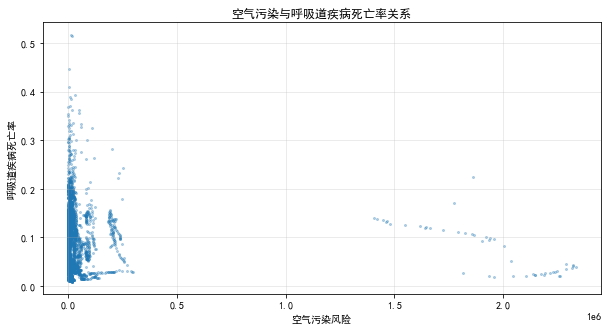

In [33]:
# 筛选呼吸道疾病
df_resp = df_final[df_final['cause'] == 'Respiratory infections and tuberculosis']
print(f"呼吸道疾病数据量：{len(df_resp)}")

plt.figure(figsize=(10,5))
plt.scatter(df_resp['空气污染'], df_resp['val'], alpha=0.3, s=4)
plt.title('空气污染与呼吸道疾病死亡率关系')
plt.xlabel('空气污染风险')
plt.ylabel('呼吸道疾病死亡率')
plt.grid(alpha=0.3)
plt.show()

营养缺乏数据量：4128


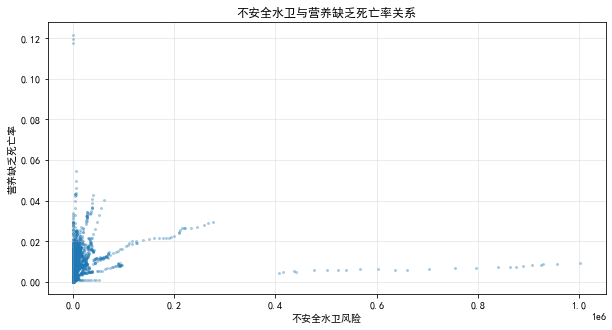

In [34]:
# 筛选营养缺乏类疾病
df_nutri = df_final[df_final['cause'] == 'Nutritional deficiencies']
print(f"营养缺乏数据量：{len(df_nutri)}")

plt.figure(figsize=(10,5))
plt.scatter(df_nutri['不安全的水，环境卫生和洗手'], df_nutri['val'], alpha=0.3, s=4)
plt.title('不安全水卫与营养缺乏死亡率关系')
plt.xlabel('不安全水卫风险')
plt.ylabel('营养缺乏死亡率')
plt.grid(alpha=0.3)
plt.show()

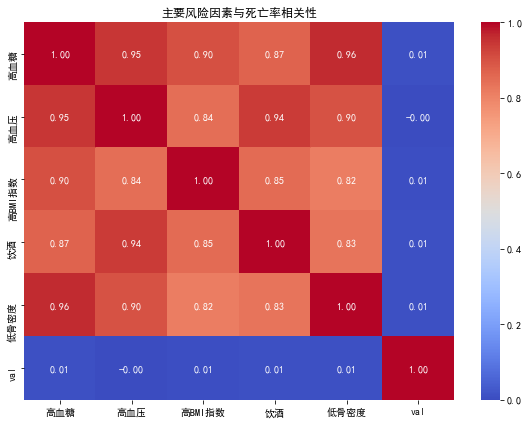

In [35]:
import seaborn as sns

# 选几个主要风险
risks = ['高血糖','高血压','高BMI指数','饮酒','低骨密度','val']
corr = df_final[risks].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('主要风险因素与死亡率相关性')
plt.tight_layout()
plt.show()

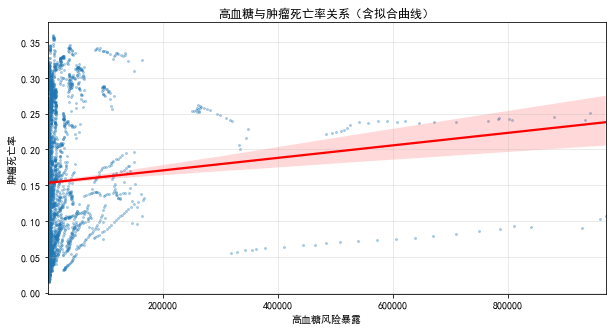

In [36]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.regplot(x=df_cancer['高血糖'], y=df_cancer['val'], scatter_kws={'alpha':0.3, 's':4}, line_kws={'color':'red'})
plt.title('高血糖与肿瘤死亡率关系（含拟合曲线）')
plt.xlabel('高血糖风险暴露')
plt.ylabel('肿瘤死亡率')
plt.grid(alpha=0.3)
plt.show()

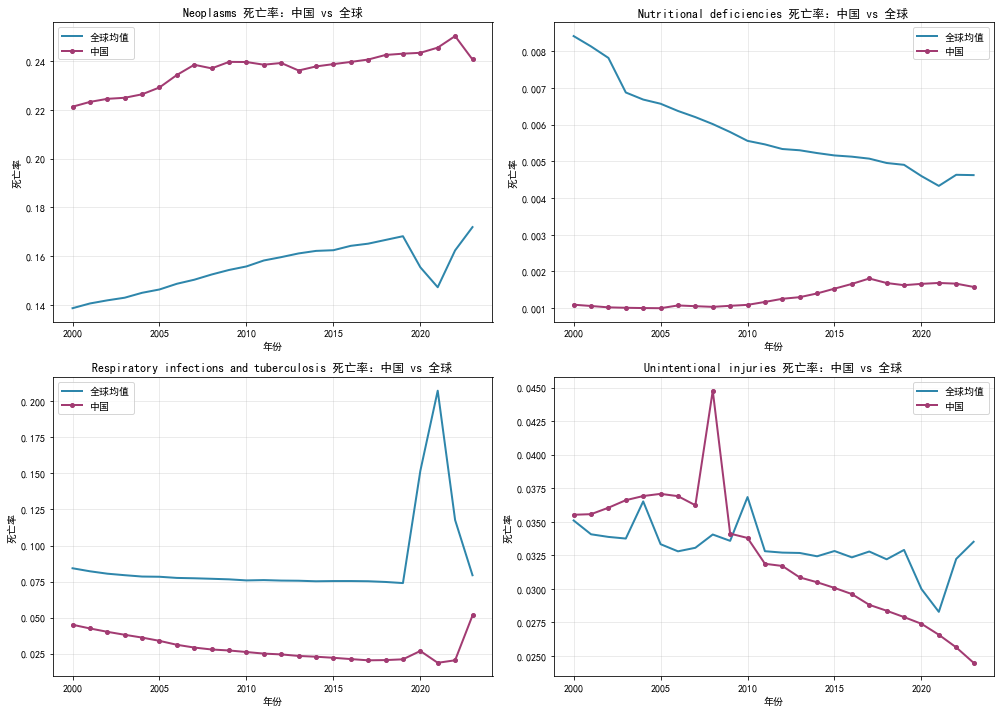

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 计算全球按年份+疾病的平均死亡率
global_trend = df_final.groupby(['year', 'cause'])['val'].mean().unstack()

# 2. 提取中国数据（按国家名筛选，注意大小写匹配）
china_data = df_final[df_final['country'].str.strip().str.lower() == 'china']
china_trend = china_data.groupby(['year', 'cause'])['val'].mean().unstack()

# 3. 绘图：分4个子图，对比中国与全球
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
causes = global_trend.columns

for i, cause in enumerate(causes):
    ax = axes[i]
    # 画全球均值
    ax.plot(global_trend.index, global_trend[cause], label='全球均值', color='#2E86AB', linewidth=2)
    # 画中国数据
    ax.plot(china_trend.index, china_trend[cause], label='中国', color='#A23B72', linewidth=2, marker='o', markersize=4)
    ax.set_title(f'{cause} 死亡率：中国 vs 全球')
    ax.set_xlabel('年份')
    ax.set_ylabel('死亡率')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# 筛选中国数据
china_df = df_final[df_final['country'].str.strip().str.lower() == 'china']
# 按年份取均值（消除多疾病重复值）
china_yearly = china_df.groupby('year')[['gini', 'edu_exp', 'uhc']].mean()

plt.figure(figsize=(12, 6))
# 画三条时间轨迹
plt.plot(china_yearly.index, china_yearly['gini'], label='基尼系数(gini)', color='#2E86AB', linewidth=2)
plt.plot(china_yearly.index, china_yearly['edu_exp'], label='教育支出(edu_exp)', color='#A23B72', linewidth=2)
plt.plot(china_yearly.index, china_yearly['uhc'], label='全民医保覆盖(uhc)', color='#F18F01', linewidth=2)

plt.title('中国核心社会经济指标 2000-2023年时间轨迹')
plt.xlabel('年份')
plt.ylabel('指标值')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: "Columns not found: 'gini', 'uhc', 'edu_exp'"

In [39]:
print("=== df_final所有列名 ===")
print(df_final.columns.tolist())

=== df_final所有列名 ===
['population_group', 'measure', 'country', 'sex', 'age', 'cause', 'metric', 'year', 'val', 'upper', 'lower', '不安全性', '不安全的水，环境卫生和洗手', '亲密伴侣间的暴力', '低骨密度', '体温', '儿童和孕产妇营养不良', '其他环境危险因素', '烟草烟雾', '用药', '空气污染', '职业风险', '肾脏功能受损', '身体活动不足', '饮酒', '饮食风险', '高BMI指数', '高低密度脂蛋白胆固醇', '高血压', '高血糖']


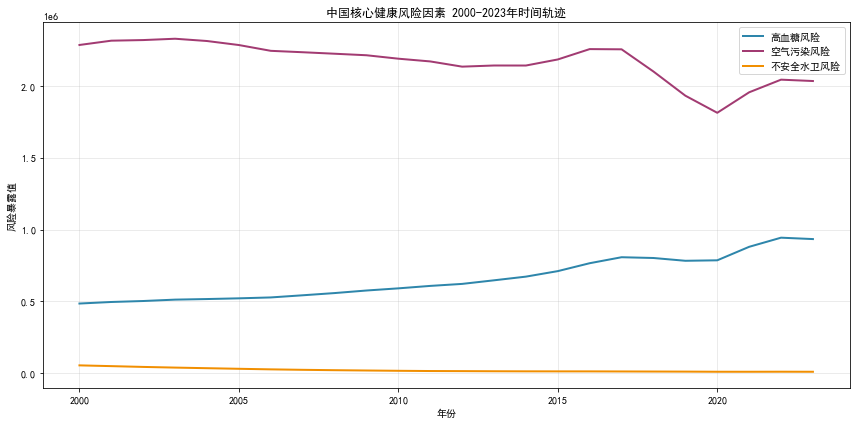

In [40]:
# 筛选中国数据
china_df = df_final[df_final['country'].str.strip().str.lower() == 'china']
# 按年份取均值（消除多疾病重复值）
china_yearly = china_df.groupby('year')[['高血糖', '空气污染', '不安全的水，环境卫生和洗手']].mean()

plt.figure(figsize=(12, 6))
# 画三条核心风险的时间轨迹
plt.plot(china_yearly.index, china_yearly['高血糖'], label='高血糖风险', color='#2E86AB', linewidth=2)
plt.plot(china_yearly.index, china_yearly['空气污染'], label='空气污染风险', color='#A23B72', linewidth=2)
plt.plot(china_yearly.index, china_yearly['不安全的水，环境卫生和洗手'], label='不安全水卫风险', color='#F18F01', linewidth=2)

plt.title('中国核心健康风险因素 2000-2023年时间轨迹')
plt.xlabel('年份')
plt.ylabel('风险暴露值')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()